Instrumentos encontrados: ('ASRL4::INSTR',)
Instrumento conectado satisfactoriamente: GW,GDS-1102A-U,GES170725,V1.14
Escala vertical: 1.00 [V/div]
b'#48008'
Periodo de muestreo = 20 [ns]
Cantidad de muestras = 4000


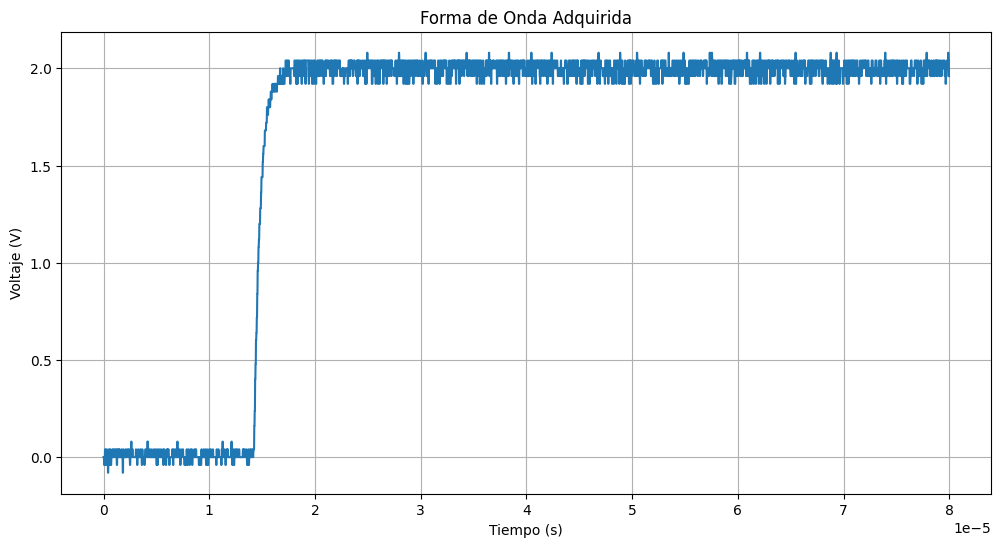

Conexión con el instrumento cerrada exitosamente.
Gestor de recursos cerrado exitosamente.


In [10]:
import time
from struct import unpack
import sys
import pyvisa
import matplotlib.pyplot as plt
import numpy as np

def init_system():
    rm = pyvisa.ResourceManager()
    instrument_list = rm.list_resources()
    print("Instrumentos encontrados:", instrument_list)
    return rm

def init_instrument(manager, resource_name):
    try:
        dso = manager.open_resource(resource_name)
        dso.read_termination = '\n'
        dso.write_termination = '\n'
        idn = dso.query('*IDN?')
        print("Instrumento conectado satisfactoriamente:", idn)
    except Exception as e:
        print("Error al iniciar con el instrumento:", e)
        close_system()
    return dso

def get_block_data(channel):
    try:
        v_div = get_channel_scale(channel)
        dso.write(f':acquire{channel}:state?')
        state = dso.read()
        if(state[0] == '1'):
            time.sleep(0.1)
            dso.write(f":acquire{channel}:memory?")
            inBuffer = dso.read_bytes(10)
            length = len(inBuffer)
            headerlen = 2 + int(chr(inBuffer[1]))
            pkg_length = int(inBuffer[2:headerlen]) + headerlen
            pkg_length = pkg_length - length
            
            while True:
                if(pkg_length==0):
                    break
                else:
                    if(pkg_length > 100000):
                        length = 100000
                    else:
                        length = pkg_length
                    try:
                        buf = dso.read_bytes(length)
                    except:
                        print('Error al recibir datos del instrumento!')
                        close_system()
                        sys.exit(0)
                    
                    num = len(buf)
                    inBuffer += buf
                    pkg_length = pkg_length - num
            waveform, dt = unpack_waveform(inBuffer, headerlen, v_div)
            return waveform, dt
        else:
            print('Error: Forma de onda aún no está lista.')
    except Exception as e:
        print("Error al obtener datos:", e)
        close_system()
        return None, None

def unpack_waveform(inBuffer, headerlen, vdiv):
    print(inBuffer[:headerlen])
    dt = unpack('>f', inBuffer[headerlen : headerlen + 4])[0]
    #print(f'Periodo de muestreo = {dt} [s]')
    print(f'Periodo de muestreo = {dt*1e9:.0f} [ns]')
    waveform_raw = unpack('>%sh' % (int(len(inBuffer[headerlen + 8:]) / 2)), inBuffer[headerlen + 8:])
    num = len(waveform_raw)
    print(f'Cantidad de muestras = {num}')
    waveform = [0] * num
    for i in range(num):
        waveform[i] = waveform_raw[i] * vdiv / 25
    return waveform, dt

def get_channel_scale(channel):
    try:
        scale = dso.query(f':channel{channel}:scale?')
        v_scale = float(scale)
        print(f'Escala vertical: {v_scale:.2f} [V/div]')
        return v_scale
    except Exception as e:
        print("Error al obtener la escala vertical:", e)
        close_system()

def plot_waveform(waveform, dt):
    num_points = len(waveform)
    time_axis = np.linspace(0, (num_points - 1) * dt, num_points)
    plt.figure(figsize=(12, 6))
    plt.plot(time_axis, waveform)
    plt.title("Forma de Onda Adquirida")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (V)")
    plt.grid(True)
    plt.show()

def close_instrument():
    try:
        dso.close()
        print("Conexión con el instrumento cerrada exitosamente.")
    except Exception as e:
        print("Error al cerrar la conexión con el instrumento:", e)

def close_system():
    try:
        close_instrument()
        resource_manager.close()
        print("Gestor de recursos cerrado exitosamente.")
    except Exception as e:
        print("Error al cerrar el gestor de recursos:", e)
        close_system()

if __name__ == '__main__':
    resource_manager = init_system()
    dso = init_instrument(resource_manager, 'ASRL4::INSTR')
    

    wave_form, dt = get_block_data(1)
    if wave_form is not None:
        plot_waveform(wave_form, dt)

    '''
    
    '''
    close_system()